In [1]:
import pandas as pd

In [2]:
embedding_dims = 32
random_state = 2020
n_transactions_context = 20
n_examples = 16000  # 16000 = Full
input_dim = 1537

#### Objective:

Evaluate the generated fraud detection model.

#### Depends on:

In [3]:
triplet_loss_model_fname = "./data/triplet_loss_model_4_agencies.pth"
fraud_detection_model_fname = "./data/fraud_detection_model_4_agencies.pth"
X_test_output_fname = "./data/X_test_4_agencies.jbl"
y_test_output_fname = "./data/y_test_4_agencies.jbl"

--------------

In [4]:
import torch
import numpy as np
import random
from sklearn import model_selection
import torch.nn as nn
import copy
from tqdm.notebook import tqdm

In [5]:
torch.manual_seed(random_state)
np.random.seed(random_state)
random.seed(random_state)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

if device.type == "cuda":
    torch.cuda.get_device_name()

In [6]:
class EmbeddingModel(nn.Module):
    def __init__(self, input_dim=1537, emb_dim=32):
        super(EmbeddingModel, self).__init__()

        self.fc = nn.Sequential(
            nn.Linear(input_dim, input_dim),
            nn.PReLU(),
            nn.Linear(input_dim, 1024),
            nn.PReLU(),
            nn.Linear(1024, 1024),
            nn.PReLU(),
            nn.Linear(1024, 128),
            nn.PReLU(),
            nn.Linear(128, 64),
            nn.PReLU(),
            nn.Linear(64, 64),
            nn.PReLU(),
            nn.Linear(64, emb_dim),
        )

    def forward(self, x):
        x = self.fc(x)
        return x

In [7]:
class Classifier(nn.Module):
    def __init__(self, embedding_model, n_transactions_context, embedding_dims):
        super(Classifier, self).__init__()

        self.n_transactions_context = n_transactions_context
        self.embedding_dims = embedding_dims

        emb_models = []

        for i in range(n_transactions_context + 1):
            emb_models.append(copy.deepcopy(embedding_model))

        self.emb_models = nn.ModuleList(emb_models)

        self.fc = nn.Sequential(
            nn.Linear((n_transactions_context + 1) * embedding_dims, 512),
            nn.PReLU(),
            nn.Linear(512, 256),
            nn.PReLU(),
            nn.Linear(256, 128),
            nn.PReLU(),
            nn.Linear(128, 32),
            nn.PReLU(),
            nn.Linear(32, 1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        # print(x.shape)

        embs = [model(x[:, i]) for i, model in enumerate(self.emb_models)]

        # print("len(embs)", len(embs))

        # print("embs[0].shape", embs[0].shape)

        cat = torch.cat(embs, dim=1)

        # print("cat.shape", cat.shape)

        flat = cat.flatten(start_dim=1)

        # print("flat.shape", flat.shape)

        x = self.fc(flat)

        return x

In [8]:
emb_model = EmbeddingModel(input_dim, embedding_dims)

emb_model.eval()

EmbeddingModel(
  (fc): Sequential(
    (0): Linear(in_features=1537, out_features=1537, bias=True)
    (1): PReLU(num_parameters=1)
    (2): Linear(in_features=1537, out_features=1024, bias=True)
    (3): PReLU(num_parameters=1)
    (4): Linear(in_features=1024, out_features=1024, bias=True)
    (5): PReLU(num_parameters=1)
    (6): Linear(in_features=1024, out_features=128, bias=True)
    (7): PReLU(num_parameters=1)
    (8): Linear(in_features=128, out_features=64, bias=True)
    (9): PReLU(num_parameters=1)
    (10): Linear(in_features=64, out_features=64, bias=True)
    (11): PReLU(num_parameters=1)
    (12): Linear(in_features=64, out_features=32, bias=True)
  )
)

In [9]:
emb_model.load_state_dict(torch.load(triplet_loss_model_fname))

<All keys matched successfully>

In [10]:
cl_model = Classifier(emb_model, n_transactions_context, embedding_dims)

In [11]:
cl_model.load_state_dict(torch.load(fraud_detection_model_fname))

<All keys matched successfully>

In [12]:
cl_model.eval()

Classifier(
  (emb_models): ModuleList(
    (0-20): 21 x EmbeddingModel(
      (fc): Sequential(
        (0): Linear(in_features=1537, out_features=1537, bias=True)
        (1): PReLU(num_parameters=1)
        (2): Linear(in_features=1537, out_features=1024, bias=True)
        (3): PReLU(num_parameters=1)
        (4): Linear(in_features=1024, out_features=1024, bias=True)
        (5): PReLU(num_parameters=1)
        (6): Linear(in_features=1024, out_features=128, bias=True)
        (7): PReLU(num_parameters=1)
        (8): Linear(in_features=128, out_features=64, bias=True)
        (9): PReLU(num_parameters=1)
        (10): Linear(in_features=64, out_features=64, bias=True)
        (11): PReLU(num_parameters=1)
        (12): Linear(in_features=64, out_features=32, bias=True)
      )
    )
  )
  (fc): Sequential(
    (0): Linear(in_features=672, out_features=512, bias=True)
    (1): PReLU(num_parameters=1)
    (2): Linear(in_features=512, out_features=256, bias=True)
    (3): PReLU(num_

In [13]:
import joblib

with open(X_test_output_fname, "rb") as f:
    X = joblib.load(f)

with open(y_test_output_fname, "rb") as f:
    y = joblib.load(f)

In [14]:
X = X[:n_examples]
y = y[:n_examples]

In [15]:
with torch.no_grad():
    sample = X[:2].astype("float32")
    # print(sample.shape)
    sample_prediction = cl_model(torch.from_numpy(sample).cpu()).cpu().numpy()

sample_prediction

array([[0.67046005],
       [0.19967715]], dtype=float32)

In [16]:
len(X)

16000

In [17]:
cl_model.eval()
with torch.no_grad():
    pred = cl_model(torch.from_numpy(X.astype("float32")).cpu()).cpu().numpy()

In [18]:
from plothelpers import KS, PSI, ScoreDistribution
import matplotlib.pyplot as plt

In [19]:
pred.shape, y.shape

((16000, 1), (16000,))

In [20]:
len(y.shape)

1

In [21]:
pred.sum()

7910.207

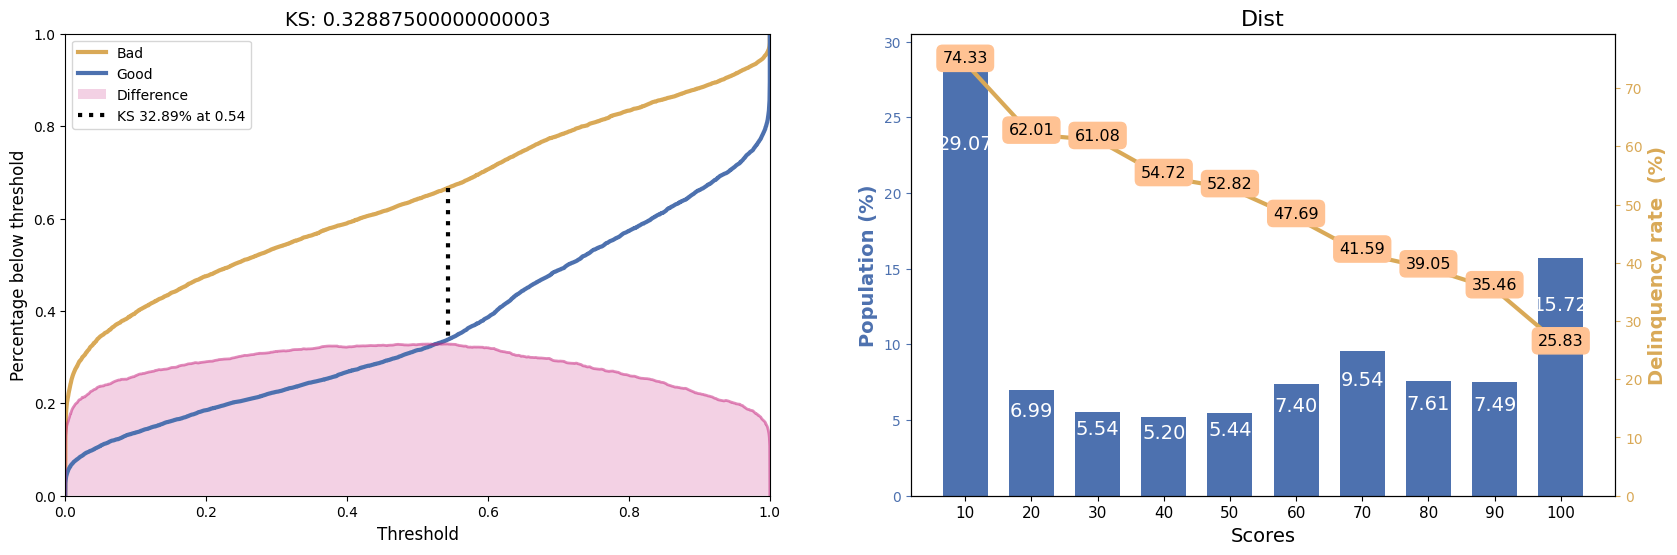

In [22]:
fig, axis = plt.subplots(1, 2, figsize=(20, 6), sharey=False, facecolor=(1, 1, 1))

ks = KS(pred.reshape(-1), y)

ks_value = ks.value

title = f"KS: {ks_value}"

ks.plot(title=title, ax=axis[0])

ScoreDistribution(pred.reshape(-1), y).plot("Dist", ax=axis[1])

In [23]:
# ks.threshold

In [24]:
max_diff_index = ks.diffs.argmax()

In [25]:
cut = ks.distribution[max_diff_index, 0]

In [26]:
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
)

In [27]:
y.shape

(16000,)

In [28]:
pred.shape

(16000, 1)

In [29]:
cm = confusion_matrix(y, pred.reshape(-1) > cut)

In [30]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

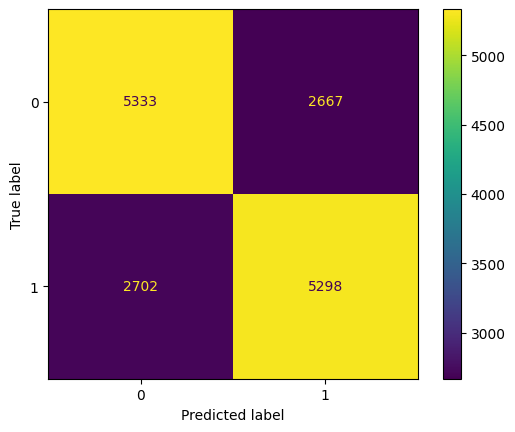

In [31]:
disp.plot()

In [32]:
precision, recall, fbeta, _ = precision_recall_fscore_support(
    y, pred.reshape(-1) > cut, average="binary"
)

In [33]:
precision, recall, fbeta

(0.6651600753295669, 0.66225, 0.6637018477920451)